# Semana 2: Análisis Exploratorio y Feature Engineering
## Notebook Conceptual (NB1) – Manipulación de Datos Dummy

**Propósito:** Aprender a explorar, limpiar y transformar datos reales simulados (dummy). Introducimos el concepto de pipeline y transformadores de scikit-learn, sentando las bases para los modelos.

**Docente:** Carlos César Sánchez Coronel

---

## 0. Configuración Inicial

Importamos las librerías necesarias: Pandas para manipulación, NumPy para operaciones numéricas, Matplotlib y Seaborn para visualización, y varios módulos de scikit-learn para preprocesamiento y pipelines.

In [1]:
# Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
np.random.seed(42)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


---
## 1. Generación de un Dataset Dummy

Creamos un conjunto de datos sintético que contenga:
- Variables numéricas (con y sin outliers)
- Variables categóricas (nominales y ordinales)
- Valores nulos

Esto nos permitirá practicar todas las técnicas de limpieza y transformación en un entorno controlado.

In [3]:
# Fijamos tamaño del dataset
n_samples = 1000

# Generamos variables numéricas
edad = np.random.randint(18, 70, size=n_samples)
ingreso = np.random.normal(loc=50000, scale=15000, size=n_samples).astype(int)
gasto_mensual = np.random.gamma(shape=2, scale=1000, size=n_samples).astype(int)

# Introducimos outliers en ingresos (algunos valores extremos)
ingreso_outliers = ingreso.copy()
outlier_idx = np.random.choice(n_samples, size=10, replace=False)
ingreso_outliers[outlier_idx] = ingreso_outliers[outlier_idx] * 5  # multiplicamos por 5

# Variable categórica nominal (ciudad)
ciudades = ['Madrid', 'Barcelona', 'Valencia', 'Sevilla', 'Bilbao']
ciudad = np.random.choice(ciudades, size=n_samples, p=[0.3, 0.25, 0.2, 0.15, 0.1])

# Variable categórica ordinal (nivel educativo)
educacion = np.random.choice(['Primaria', 'Secundaria', 'Grado', 'Máster', 'Doctorado'],
                              size=n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# Introducimos valores nulos en gasto_mensual (5% aprox)
# Convertimos a float para permitir valores NaN
gasto_mensual_con_nulos = gasto_mensual.astype(float)
nulos_idx = np.random.choice(n_samples, size=int(0.05*n_samples), replace=False)
gasto_mensual_con_nulos[nulos_idx] = np.nan

# Creamos el DataFrame
df = pd.DataFrame({
    'edad': edad,
    'ingreso': ingreso_outliers,
    'gasto_mensual': gasto_mensual_con_nulos,
    'ciudad': ciudad,
    'educacion': educacion
})

# Mostramos las primeras filas
df.head()

,edad,ingreso,gasto_mensual,ciudad,educacion
0,22,35265,502.0,Valencia,Máster
1,57,34973,911.0,Barcelona,Secundaria
2,36,42837,823.0,Valencia,Secundaria
3,35,55595,1076.0,Valencia,Grado
4,67,50960,2947.0,Sevilla,Primaria


---
## 2. Exploración Inicial y Estadísticas Descriptivas

Antes de cualquier transformación, debemos entender la estructura general del dataset: dimensiones, tipos de datos, presencia de nulos, y estadísticas básicas.

In [4]:
# Dimensiones del dataset
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")
print("\n")

# Información general (tipos de datos y nulos)
df.info()

Número de filas: 1000
Número de columnas: 5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   edad           1000 non-null   int64  
 1   ingreso        1000 non-null   int64  
 2   gasto_mensual  950 non-null    float64
 3   ciudad         1000 non-null   object 
 4   educacion      1000 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 39.2+ KB


In [5]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,ingreso,gasto_mensual
count,1000.000000,1000.000000,950.000000
mean,43.059000,52157.012000,1972.731579
std,15.061885,25275.285584,1370.735599
min,18.000000,7593.000000,67.000000
25%,30.000000,39952.500000,894.250000
50%,43.000000,50574.500000,1667.000000
75%,56.000000,61186.000000,2754.250000
max,69.000000,297135.000000,10189.000000


In [6]:
# Frecuencias de variables categóricas
print("Frecuencia de ciudades:")
print(df['ciudad'].value_counts())
print("\nFrecuencia de niveles educativos:")
print(df['educacion'].value_counts())

Frecuencia de ciudades:
ciudad
Madrid       306
Barcelona    253
Valencia     198
Sevilla      142
Bilbao       101
Name: count, dtype: int64

Frecuencia de niveles educativos:
educacion
Grado         378
Secundaria    296
Máster        151
Primaria      114
Doctorado      61
Name: count, dtype: int64


---
## 3. Visualizaciones Univariadas

Usamos histogramas, boxplots y countplots para entender la distribución de cada variable.

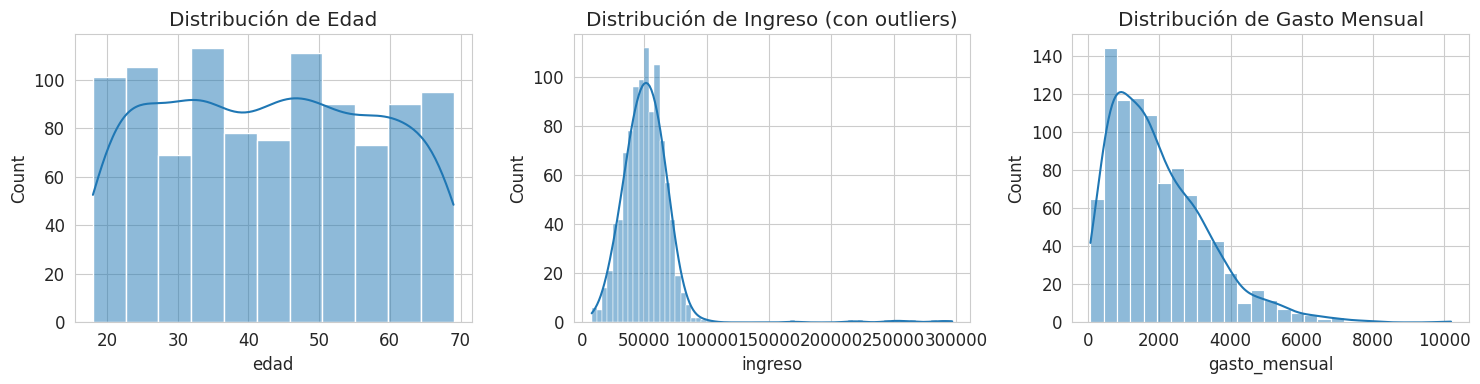

In [7]:
# Histogramas de variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['edad'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de Edad')

sns.histplot(df['ingreso'], kde=True, ax=axes[1])
axes[1].set_title('Distribución de Ingreso (con outliers)')

sns.histplot(df['gasto_mensual'].dropna(), kde=True, ax=axes[2])
axes[2].set_title('Distribución de Gasto Mensual')

plt.tight_layout()
plt.show()

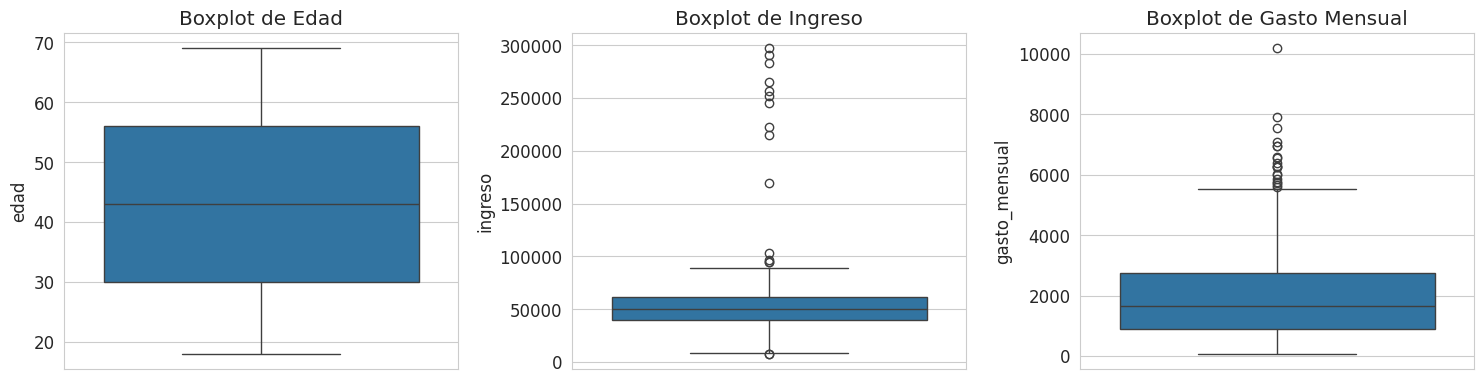

In [8]:
# Boxplots para detectar outliers visualmente
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df['edad'], ax=axes[0])
axes[0].set_title('Boxplot de Edad')

sns.boxplot(y=df['ingreso'], ax=axes[1])
axes[1].set_title('Boxplot de Ingreso')

sns.boxplot(y=df['gasto_mensual'].dropna(), ax=axes[2])
axes[2].set_title('Boxplot de Gasto Mensual')

plt.tight_layout()
plt.show()

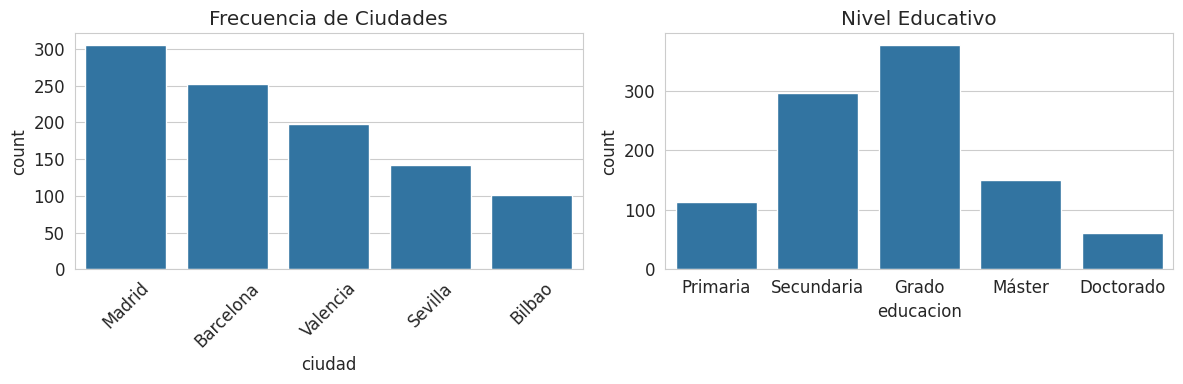

In [9]:
# Countplots para variables categóricas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='ciudad', ax=axes[0], order=df['ciudad'].value_counts().index)
axes[0].set_title('Frecuencia de Ciudades')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='educacion', ax=axes[1], order=['Primaria', 'Secundaria', 'Grado', 'Máster', 'Doctorado'])
axes[1].set_title('Nivel Educativo')

plt.tight_layout()
plt.show()

---
## 4. Correlaciones (Pearson y Spearman)

Estudiamos las relaciones entre variables numéricas. La correlación de Pearson mide relaciones lineales, mientras que Spearman mide relaciones monótonas (basadas en rangos).

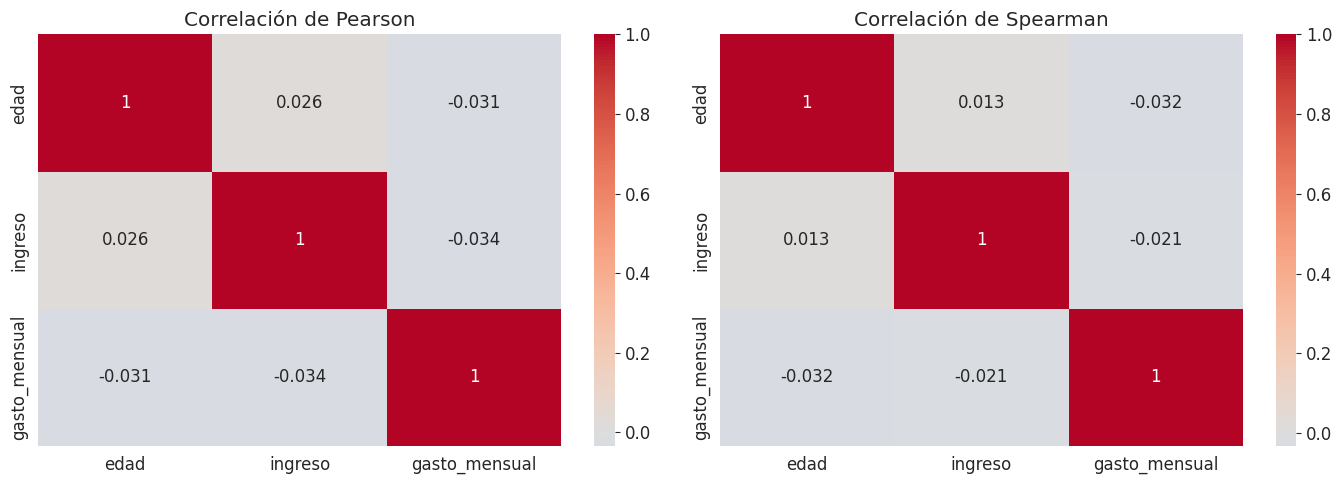

In [10]:
# Seleccionamos solo variables numéricas
df_numerico = df[['edad', 'ingreso', 'gasto_mensual']].dropna()

# Matriz de correlación de Pearson
pearson_corr = df_numerico.corr(method='pearson')
spearman_corr = df_numerico.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Correlación de Pearson')

sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlación de Spearman')

plt.tight_layout()
plt.show()

---
## 5. Detección de Outliers usando Rango Intercuartílico (IQR)

El método IQR define como outlier cualquier valor fuera del intervalo [Q1 - 1.5*IQR, Q3 + 1.5*IQR].

In [11]:
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return (serie < limite_inferior) | (serie > limite_superior)

# Aplicamos a las variables numéricas
outliers_edad = detectar_outliers_iqr(df['edad'])
outliers_ingreso = detectar_outliers_iqr(df['ingreso'])
outliers_gasto = detectar_outliers_iqr(df['gasto_mensual'].dropna())

print(f"Outliers en edad: {outliers_edad.sum()} ({outliers_edad.mean()*100:.2f}%)")
print(f"Outliers en ingreso: {outliers_ingreso.sum()} ({outliers_ingreso.mean()*100:.2f}%)")
print(f"Outliers en gasto_mensual: {outliers_gasto.sum()} ({outliers_gasto.mean()*100:.2f}%)")

# Mostramos algunos ejemplos de outliers en ingreso
df[outliers_ingreso][['ingreso']].head(10)

Outliers en edad: 0 (0.00%)
Outliers en ingreso: 16 (1.60%)
Outliers en gasto_mensual: 19 (2.00%)


,ingreso
45,290425
150,169755
177,283095
314,94726
333,94413
373,297135
472,251765
492,214965
625,96422
674,7779


---
## 6. Imputación de Valores Nulos

Vamos a imputar los valores nulos de 'gasto_mensual' usando diferentes estrategias con `SimpleImputer` de scikit-learn.

In [12]:
from sklearn.impute import SimpleImputer

# Extraemos la columna con nulos
gasto_nulos = df[['gasto_mensual']].copy()

# Imputación por media
imputer_mean = SimpleImputer(strategy='mean')
gasto_mean = imputer_mean.fit_transform(gasto_nulos)

# Imputación por mediana
imputer_median = SimpleImputer(strategy='median')
gasto_median = imputer_median.fit_transform(gasto_nulos)

# Imputación por moda (most frequent)
imputer_mode = SimpleImputer(strategy='most_frequent')
gasto_mode = imputer_mode.fit_transform(gasto_nulos)

# Comparamos estadísticas
print("Estadísticas originales (sin nulos):")
print(df['gasto_mensual'].dropna().describe())
print("\nEstadísticas tras imputar con media:")
print(pd.Series(gasto_mean.flatten()).describe())
print("\nEstadísticas tras imputar con mediana:")
print(pd.Series(gasto_median.flatten()).describe())

Estadísticas originales (sin nulos):
count      950.000000
mean      1972.731579
std       1370.735599
min         67.000000
25%        894.250000
50%       1667.000000
75%       2754.250000
max      10189.000000
Name: gasto_mensual, dtype: float64

Estadísticas tras imputar con media:
count     1000.000000
mean      1972.731579
std       1335.992604
min         67.000000
25%        931.000000
50%       1749.500000
75%       2649.750000
max      10189.000000
dtype: float64

Estadísticas tras imputar con mediana:
count     1000.000000
mean      1957.445000
std       1337.654886
min         67.000000
25%        931.000000
50%       1667.000000
75%       2649.750000
max      10189.000000
dtype: float64


---
## 7. Codificación de Variables Categóricas

Convertimos las variables categóricas a formato numérico usando `OneHotEncoder` (para nominales) y `LabelEncoder` / `OrdinalEncoder` (para ordinales).

In [13]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder

# One-Hot Encoding para 'ciudad'
onehot = OneHotEncoder(sparse_output=False)
ciudad_onehot = onehot.fit_transform(df[['ciudad']])

# Convertimos a DataFrame para visualizar
ciudad_onehot_df = pd.DataFrame(ciudad_onehot, columns=onehot.get_feature_names_out(['ciudad']))
ciudad_onehot_df.head()

,ciudad_Barcelona,ciudad_Bilbao,ciudad_Madrid,ciudad_Sevilla,ciudad_Valencia
0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0


In [14]:
# Ordinal Encoding para 'educacion' (respetando el orden)
orden_educacion = [['Primaria', 'Secundaria', 'Grado', 'Máster', 'Doctorado']]
ordinal = OrdinalEncoder(categories=orden_educacion)
educacion_ordinal = ordinal.fit_transform(df[['educacion']])

df_educacion_ordinal = df[['educacion']].copy()
df_educacion_ordinal['educacion_ordinal'] = educacion_ordinal.astype(int)
df_educacion_ordinal.head(10)

,educacion,educacion_ordinal
0,Máster,3
1,Secundaria,1
2,Secundaria,1
3,Grado,2
4,Primaria,0
5,Grado,2
6,Primaria,0
7,Secundaria,1
8,Grado,2
9,Grado,2


---
## 8. Escalado de Variables Numéricas

Escalamos las variables para que tengan media 0 y desviación 1 (StandardScaler) o para que estén en un rango [0,1] (MinMaxScaler).

In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Seleccionamos variables numéricas (sin nulos)
df_num_sin_nulos = df[['edad', 'ingreso', 'gasto_mensual']].dropna()

# StandardScaler
scaler_std = StandardScaler()
df_std = scaler_std.fit_transform(df_num_sin_nulos)
df_std = pd.DataFrame(df_std, columns=df_num_sin_nulos.columns)

# MinMaxScaler
scaler_mm = MinMaxScaler()
df_mm = scaler_mm.fit_transform(df_num_sin_nulos)
df_mm = pd.DataFrame(df_mm, columns=df_num_sin_nulos.columns)

# Comparamos estadísticas
print("Original - media:")
print(df_num_sin_nulos.mean())
print("\nStandardScaler - media (aprox 0):")
print(df_std.mean())
print("\nMinMaxScaler - min/max:")
print(df_mm.min())
print(df_mm.max())

Original - media:
edad                42.972632
ingreso          52187.508421
gasto_mensual     1972.731579
dtype: float64

StandardScaler - media (aprox 0):
edad            -2.169025e-16
ingreso         -5.001847e-17
gasto_mensual   -4.207161e-17
dtype: float64

MinMaxScaler - min/max:
edad             0.0
ingreso          0.0
gasto_mensual    0.0
dtype: float64
edad             1.0
ingreso          1.0
gasto_mensual    1.0
dtype: float64


---
## 9. Construcción de un Pipeline con ColumnTransformer

Unimos todos los pasos de preprocesamiento en un solo pipeline usando `ColumnTransformer`. Esto nos permite aplicar transformaciones diferentes a distintos tipos de columnas y evitar data leakage.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definimos las columnas por tipo
numeric_features = ['edad', 'ingreso', 'gasto_mensual']
categorical_nominal = ['ciudad']
categorical_ordinal = ['educacion']

# Pipeline para numéricas: imputar por mediana y escalar con StandardScaler
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para nominales: one-hot encoding
nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline para ordinales: ordinal encoding respetando orden
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[['Primaria', 'Secundaria', 'Grado', 'Máster', 'Doctorado']]))
])

# Combinamos todo en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('nom', nominal_transformer, categorical_nominal),
        ('ord', ordinal_transformer, categorical_ordinal)
    ])

# Aplicamos el preprocesador a nuestros datos
X_processed = preprocessor.fit_transform(df)

print(f"Dimensiones de los datos transformados: {X_processed.shape}")
print("\nPrimeras 5 filas del array transformado:")
print(X_processed[:5, :])

Dimensiones de los datos transformados: (1000, 9)

Primeras 5 filas del array transformado:
[[-1.39886458 -0.66865572 -1.08860161  0.          0.          0.
   0.          1.          3.        ]
 [ 0.9260445  -0.68021429 -0.78268964  1.          0.          0.
   0.          0.          1.        ]
 [-0.46890095 -0.36892463 -0.84850933  0.          0.          0.
   0.          1.          1.        ]
 [-0.53532692  0.13608979 -0.65927771  0.          0.          0.
   0.          1.          2.        ]
 [ 1.59030424 -0.04738269  0.7401387   0.          0.          0.
   1.          0.          0.        ]]


---
## 10. Importancia de la Escala (Demostración)

Mostramos por qué es necesario escalar: en algoritmos basados en distancias (KNN, SVM) o que usan regularización, las variables con escalas grandes dominan el cálculo.

In [17]:
from sklearn.neighbors import NearestNeighbors

# Datos sin escalar
X_unscaled = df[['edad', 'ingreso']].dropna().values[:100]

# Datos escalados (StandardScaler)
scaler_demo = StandardScaler()
X_scaled = scaler_demo.fit_transform(X_unscaled)

# Calculamos vecinos más cercanos
knn_unscaled = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn_unscaled.fit(X_unscaled)

knn_scaled = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn_scaled.fit(X_scaled)

# Tomamos un punto de ejemplo
punto = X_unscaled[0].reshape(1, -1)
punto_scaled = scaler_demo.transform(punto)

print("Vecinos sin escalar (distancias dominadas por ingreso):")
distancias_unscaled, indices_unscaled = knn_unscaled.kneighbors(punto)
print("Índices de vecinos:", indices_unscaled[0])
print("Distancias:", distancias_unscaled[0])

print("\nVecinos con datos escalados (ambas variables pesan igual):")
distancias_scaled, indices_scaled = knn_scaled.kneighbors(punto_scaled)
print("Índices de vecinos:", indices_scaled[0])
print("Distancias:", distancias_scaled[0])

Vecinos sin escalar (distancias dominadas por ingreso):
Índices de vecinos: [ 0 55 10 62  1]
Distancias: [  0.          95.0210503  182.33211456 212.81212371 294.09012224]

Vecinos con datos escalados (ambas variables pesan igual):
Índices de vecinos: [ 0 55 37 87 58]
Distancias: [0.         0.13593628 0.15367026 0.29375329 0.34052904]


---
## 11. Conclusiones

Hemos cubierto:

✔️ **Generación de datos dummy** con nulos, outliers y categóricas.
✔️ **Estadísticas descriptivas y visualizaciones** (histogramas, boxplots, countplots).
✔️ **Detección de outliers** con IQR.
✔️ **Imputación de nulos** con SimpleImputer.
✔️ **Codificación de categóricas** (OneHotEncoder, OrdinalEncoder).
✔️ **Escalado** (StandardScaler, MinMaxScaler).
✔️ **Pipeline con ColumnTransformer** para preprocesar datos mixtos.
✔️ **Demostración de la importancia de la escala**.

Estas herramientas son fundamentales antes de pasar al modelado. En el próximo notebook (NB2) aplicaremos estos conceptos a un dataset real.

---
**Fin del Notebook Conceptual - Semana 2**